In [1]:
import pandas as pd

path = "/content/drive/MyDrive/CodeAlpha_SentimentAnalysis/new2_books_dataset_6_columns.csv"
df = pd.read_csv("/content/drive/MyDrive/CodeAlpha_SentimentAnalysis/new2_books_dataset_6_columns.csv", encoding="latin-1")
df.head()

,Title,Price (£),Rating,Availability,Stock Count,Category,Category.1,Amounts,Unnamed: 8,Total amount of each book
0,A Light in the Attic,51.77,Three,In stock,0.0,Unknown,Unknown,20.0,NaN,51.77
1,Tipping the Velvet,53.74,One,In stock,0.0,Unknown,Thriller,3.0,NaN,53.74
2,Soumission,50.10,One,In stock,0.0,Unknown,Music,1.0,NaN,50.10
3,Sharp Objects,47.82,Four,In stock,0.0,Unknown,Food and Drink,1.0,NaN,47.82
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,0.0,Unknown,Romance,2.0,NaN,54.23


In [2]:
!pip install nltk textblob vaderSentiment pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

In [11]:
TEXT_COLUMN = "Title"

In [12]:
df = df.dropna(subset=[TEXT_COLUMN])
df = df.reset_index(drop=True)


In [13]:
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [14]:
df["sentiment_scores"] = df[TEXT_COLUMN].apply(
    lambda x: sia.polarity_scores(str(x))
)

df["compound"] = df["sentiment_scores"].apply(lambda x: x["compound"])


In [15]:
def classify_sentiment(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["compound"].apply(classify_sentiment)


In [16]:
df[[TEXT_COLUMN, "sentiment"]].head()


,Title,sentiment
0,A Light in the Attic,neutral
1,Tipping the Velvet,neutral
2,Soumission,neutral
3,Sharp Objects,neutral
4,Sapiens: A Brief History of Humankind,neutral


In [17]:
df["polarity"] = df[TEXT_COLUMN].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

df["subjectivity"] = df[TEXT_COLUMN].apply(
    lambda x: TextBlob(str(x)).sentiment.subjectivity
)


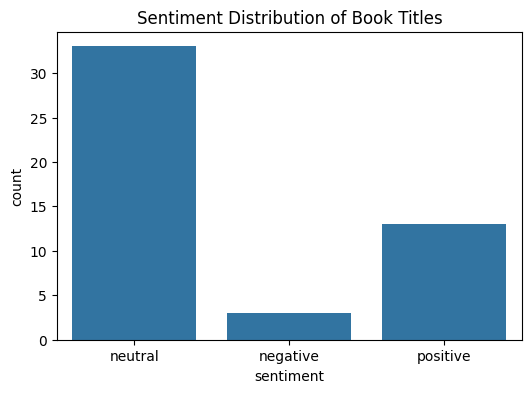

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution of Book Titles")
plt.show()


In [20]:
df["sentiment"].value_counts()


,count
sentiment,
neutral,33
positive,13
negative,3


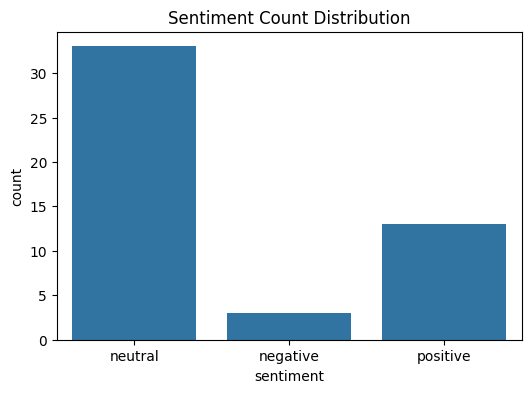

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Count Distribution")
plt.show()
